# CUHK Avenue Dataset — Pipeline Comparison
## Baseline vs Enhanced Surveillance System

Evaluates **both pipelines** on the **CUHK Avenue** dataset — a dedicated
surveillance anomaly benchmark with frame-level ground truth masks.

| | Baseline | Enhanced |
|---|---|---|
| **M2 Detection** | `yolov8n.pt` (COCO pretrained) | Fine-tuned YOLOv8 (LLVIP) |
| **M3 Tracking** | ❌ None | ✅ DeepSORT |
| **M4 ST-Analysis** | ❌ None | ✅ Dwell-time zone loitering |
| **M5 FP Reduction** | ❌ None | ✅ 15-frame stability filter |
| **NMS IoU** | 0.70 (default) | 0.45 (duplicate fix) |

### CUHK Avenue GT Format
- `ground_truth_demo/testing_label_mask/` → 21 `.mat` files (`1_label.mat` … `21_label.mat`)
- Each `.mat` contains a binary matrix: **rows = frames, cols = ???** — loaded via `scipy.io`
- A frame is labelled **abnormal (1)** if any anomaly (including loitering) is present
- Paired with `Avenue_Dataset/testing_videos/` → `01.avi` … `21.avi`

### Metrics computed
- **Detection**: Avg det/frame, zero-det%, per-frame Precision/Recall/F1 (IoU ≥ 0.50)
- **Alert (M4+M5)**: Frame-level TPR, FPR, AUROC vs GT anomaly labels
- **System**: Confirmed vs potential alerts, M5 suppression rate

## 0) Dependencies

In [9]:
# !pip install -q ultralytics opencv-python numpy pandas matplotlib scipy

## 1) Configuration

In [2]:
import os, cv2, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, OrderedDict
from scipy.spatial import distance as dist
from scipy.io import loadmat

# ── EDIT THESE ──────────────────────────────────────────────────────────────
BASELINE_WEIGHTS = 'yolov8n.pt'

# Final deployed detector: LLVIP-only fine-tuned YOLO (dark-condition model)
ENHANCED_WEIGHTS = r'runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt'

# Root of the Avenue dataset folder
AVENUE_ROOT = '../evaluationDataset'   # folder that contains testing_videos/

# Root of the ground_truth_demo folder
GT_ROOT = '../evaluationDataset/ground_truth_demo/testing_label_mask'   # folder with 1_label.mat…21_label.mat

CONF_THRESHOLD   = 0.35
NMS_IOU_BASELINE = 0.70
NMS_IOU_ENHANCED = 0.45

# Which test videos to run (1-21). Use a small subset first for quick testing.
# e.g. TEST_IDS = [1,2,3]  to test on first 3 videos only
TEST_IDS = list(range(1, 22))   # all 21 test videos

MAX_FRAMES = None   # set e.g. 300 for a quick sanity check

# Virtual zone — Avenue videos are 640×360
ZONE_POLYGON = np.array([
    [50,  50],
    [590, 50],
    [590, 310],
    [50,  310]
], np.int32)

COLOR_B = '#4878CF'
COLOR_E = '#E74C3C'

# ── Verify paths ─────────────────────────────────────────────────────────────
for p in [BASELINE_WEIGHTS, ENHANCED_WEIGHTS]:
    print(f'  {"✅" if os.path.exists(p) else "❌ NOT FOUND"}  {p}')
print()
print(f'  {"✅" if os.path.exists(AVENUE_ROOT) else "❌ NOT FOUND"}  AVENUE_ROOT: {AVENUE_ROOT}')
print(f'  {"✅" if os.path.exists(GT_ROOT)     else "❌ NOT FOUND"}  GT_ROOT    : {GT_ROOT}')

# Count available videos and GT files
# Try multiple possible subfolder structures
vid_dir = os.path.join(AVENUE_ROOT, 'Avenue Dataset', 'testing_videos')
if not os.path.exists(vid_dir):
    vid_dir = os.path.join(AVENUE_ROOT, 'testing_videos')
if not os.path.exists(vid_dir):
    vid_dir = os.path.join(AVENUE_ROOT, 'Avenue_Dataset', 'testing_videos')
vids  = sorted(Path(vid_dir).glob('*.avi'))  if os.path.exists(vid_dir)  else []
mats  = sorted(Path(GT_ROOT).glob('*.mat'))  if os.path.exists(GT_ROOT)  else []
print(f'\n  Found {len(vids)} test videos, {len(mats)} GT label files')

  ✅  yolov8n.pt
  ✅  runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt

  ✅  AVENUE_ROOT: ../evaluationDataset
  ✅  GT_ROOT    : ../evaluationDataset/ground_truth_demo/testing_label_mask

  Found 21 test videos, 21 GT label files


## 2) Pipeline Module Classes
Same M2–M5 implementations as PipelineComparison_GT.

In [3]:
from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

class PersonDetectionModule:
    def __init__(self, weights, conf=0.5, iou=0.70):
        self.model = YOLO(weights)
        self.conf  = conf
        self.iou   = iou
    def detect(self, frame):
        res = self.model(frame, conf=self.conf, iou=self.iou,
                         classes=[0], verbose=False)[0]
        dets = []
        if res.boxes is not None:
            for b in res.boxes:
                x1,y1,x2,y2 = map(int, b.xyxy[0].cpu().numpy())
                dets.append((x1,y1,x2,y2,float(b.conf[0])))
        return dets


class DeepSORTTracker:
    def __init__(self, max_age=40, n_init=3, max_cosine_distance=0.3, nn_budget=100):
        self.tracker = DeepSort(
            max_age=max_age,
            n_init=n_init,
            max_cosine_distance=max_cosine_distance,
            nn_budget=nn_budget,
        )

    def update(self, frame, dets):
        """
        dets: list of (x1, y1, x2, y2, conf)
        Returns:
            objects: dict {track_id: centroid}
            boxes:   dict {track_id: (x1,y1,x2,y2)}
        """
        ds_input = []
        for (x1, y1, x2, y2, conf) in dets:
            ds_input.append(([x1, y1, x2 - x1, y2 - y1], conf, 'person'))

        tracks = self.tracker.update_tracks(ds_input, frame=frame)

        objects = OrderedDict()
        boxes   = OrderedDict()

        for t in tracks:
            if not t.is_confirmed():
                continue

            tid = t.track_id
            l, ttop, r, b = t.to_ltrb()
            x1, y1, x2, y2 = int(l), int(ttop), int(r), int(b)
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

            objects[tid] = np.array([cx, cy])
            boxes[tid] = (x1, y1, x2, y2)

        return objects, boxes


class SpatioTemporalModule:
    def __init__(self, fps=25, loitering_threshold=10.0, zone_polygon=None):
        self.zone_polygon = zone_polygon if zone_polygon is not None else ZONE_POLYGON
        self.dwell_timers = defaultdict(int)
        self.fps = fps
        self.loitering_threshold = loitering_threshold
    def check_zone(self, centroid):
        pt = (float(centroid[0]), float(centroid[1]))
        return cv2.pointPolygonTest(self.zone_polygon, pt, False) >= 0
    def process(self, tracked_objects):
        suspicious_ids = []
        for oid, centroid in tracked_objects.items():
            if self.check_zone(centroid):
                self.dwell_timers[oid] += 1
            else:
                self.dwell_timers[oid] = 0
            if self.dwell_timers[oid] / self.fps > self.loitering_threshold:
                suspicious_ids.append(oid)
        return suspicious_ids, self.dwell_timers


class FalsePositiveReductionModule:
    def __init__(self, persistence_threshold=15):
        self.threshold = persistence_threshold
        self.counters  = defaultdict(int)
    def validate(self, oid, is_suspicious):
        if is_suspicious: self.counters[oid] += 1
        else:             self.counters[oid] = 0
        return self.counters[oid] >= self.threshold

print('✅ All module classes defined.')

✅ All module classes defined.


## 3) Ground Truth Loader

Each `.mat` file in `testing_label_mask/` contains a variable (usually `volLabel`
or a plain array) that is a **3-D binary matrix** of shape `(H, W, N_frames)`.
A pixel is 1 if it belongs to an anomalous region in that frame.

Reduce it to a **per-frame binary flag**: frame is *anomalous* if **any pixel = 1**.

In [4]:
def load_avenue_gt(gt_root, video_id):
    """
    Handles three Avenue .mat formats:
      1. Numeric ndarray  (H, W, N_frames)
      2. MATLAB cell array -> object dtype  (1, N_frames), each cell = (H,W) mask
      3. Plain 2-D numeric (N_frames, N_pixels_flat)
    Returns: np.array (N_frames,)  1=anomalous  0=normal
    """
    mat_path = os.path.join(gt_root, f'{video_id}_label.mat')
    mat      = loadmat(mat_path)
    key = [k for k in mat.keys() if not k.startswith('_')][0]
    data = mat[key]

    if data.dtype.kind in ('u','i','f','b') and data.ndim == 3:
        # Numeric 3-D (H, W, N_frames)
        if data.shape[0] < data.shape[2]:
            data = data.transpose(1, 2, 0)
        frame_flags = (data.sum(axis=(0,1)) > 0).astype(int)

    elif data.dtype == object:
        # MATLAB cell array - each element is a (H,W) binary mask
        flat = data.flatten()
        flags = []
        for cell in flat:
            arr = np.asarray(cell)
            flags.append(1 if arr.size > 0 and arr.sum() > 0 else 0)
        frame_flags = np.array(flags, dtype=int)

    elif data.ndim == 2:
        # Plain 2-D numeric (N_frames x N_pixels)
        frame_flags = (data.astype(float).sum(axis=1) > 0).astype(int)

    else:
        raise ValueError(f'Unexpected mat shape/dtype: {data.shape} {data.dtype}')

    return frame_flags


# Quick sanity check on video 1
if os.path.exists(GT_ROOT):
    try:
        flags = load_avenue_gt(GT_ROOT, 1)
        n_anom  = int(flags.sum())
        n_total = len(flags)
        print(f'Video 01 GT: {n_total} frames | {n_anom} anomalous ({100*n_anom/n_total:.1f}%)')
        print(f'First 20 frame labels: {flags[:20].tolist()}')
    except Exception as e:
        mat_path = os.path.join(GT_ROOT, '1_label.mat')
        mat = loadmat(mat_path)
        print(f'ERROR: {e}')
        for k,v in mat.items():
            if not k.startswith('_'):
                arr = v if hasattr(v,'dtype') else __import__('numpy').asarray(v)
                print(f'  key={k}  dtype={arr.dtype}  shape={arr.shape}')
                if arr.dtype == object:
                    flat = arr.flatten()
                    c0 = __import__('numpy').asarray(flat[0])
                    print(f'  cell[0] dtype={c0.dtype}  shape={c0.shape}  sum={c0.sum()}')
else:
    print('GT_ROOT not found -- update path in Section 1')


Video 01 GT: 1439 frames | 408 anomalous (28.4%)
First 20 frame labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 4) Run Both Pipelines on All Test Videos

In [5]:
def run_baseline_video(video_path, weights, conf, iou, max_frames=None):
    detector = PersonDetectionModule(weights, conf=conf, iou=iou)
    cap      = cv2.VideoCapture(video_path)
    fps_vid  = cap.get(cv2.CAP_PROP_FPS) or 25
    records  = []
    frame_i  = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if max_frames and frame_i >= max_frames: break
        dets = detector.detect(frame)
        records.append({'frame': frame_i, 'count': len(dets), 'det_boxes': dets})
        frame_i += 1
    cap.release()
    return records, fps_vid


def run_enhanced_video(video_path, weights, conf, iou, max_frames=None):
    cap      = cv2.VideoCapture(video_path)
    fps_vid  = cap.get(cv2.CAP_PROP_FPS) or 25
    detector = PersonDetectionModule(weights, conf=conf, iou=iou)
    tracker  = DeepSORTTracker(max_age=40, n_init=3, max_cosine_distance=0.3, nn_budget=100)
    analyzer = SpatioTemporalModule(fps=fps_vid, loitering_threshold=10.0,
                                    zone_polygon=ZONE_POLYGON)
    reducer  = FalsePositiveReductionModule(persistence_threshold=15)
    records  = []
    frame_i  = 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if max_frames and frame_i >= max_frames: break
        dets = detector.detect(frame)
        tracked, tracked_boxes = tracker.update(frame, dets)

        potential_ids, timers = analyzer.process(tracked)
        confirmed_ids = [oid for oid in potential_ids if reducer.validate(oid, True)]

        for oid in tracked:
            if oid not in potential_ids:
                reducer.validate(oid, False)
        records.append({
            'frame'        : frame_i,
            'count'        : len(dets),
            'det_boxes'    : dets,
            'tracked_ids'  : list(tracked.keys()),
            'tracked_boxes': dict(tracked_boxes),
            'potential_ids': potential_ids,
            'confirmed_ids': confirmed_ids,
            'timers'       : dict(timers),
        })
        frame_i += 1
    cap.release()
    return records, fps_vid


# ── Run over all selected test videos ────────────────────────────────────────
avenue_results = {}   # vid_id (int) -> {baseline, enhanced, fps, gt_flags}

# Resolve video folder
vid_dir = os.path.join(AVENUE_ROOT, 'Avenue Dataset', 'testing_videos')
if not os.path.exists(vid_dir):
    vid_dir = os.path.join(AVENUE_ROOT, 'testing_videos')
if not os.path.exists(vid_dir):
    vid_dir = os.path.join(AVENUE_ROOT, 'Avenue_Dataset', 'testing_videos')

if not os.path.exists(vid_dir):
    print('ERROR: Video folder not found. Tried:')
    print(f'  {os.path.join(AVENUE_ROOT, "Avenue Dataset", "testing_videos")}')
    print(f'  {os.path.join(AVENUE_ROOT, "testing_videos")}')
    print('Update AVENUE_ROOT so it points to the folder CONTAINING "Avenue Dataset/"')
else:
    avis = sorted(Path(vid_dir).glob('*.avi'))
    print(f'Video folder found: {vid_dir}')
    print(f'Found {len(avis)} .avi files')

for vid_id in TEST_IDS:
    vpath = os.path.join(vid_dir, f'{vid_id:02d}.avi')
    if not os.path.exists(vpath):
        print(f'⚠️  Video not found: {vpath}')
        continue

    print(f'\n── Video {vid_id:02d} ──')

    # Load GT flags
    gt_flags = None
    if os.path.exists(GT_ROOT):
        try:
            gt_flags = load_avenue_gt(GT_ROOT, vid_id)
        except Exception as e:
            print(f'   ⚠️  GT load error: {e}')

    print('  [Baseline]')
    rec_b, fps = run_baseline_video(vpath, BASELINE_WEIGHTS,
                                    CONF_THRESHOLD, NMS_IOU_BASELINE, MAX_FRAMES)

    print('  [Enhanced]')
    rec_e, _   = run_enhanced_video(vpath, ENHANCED_WEIGHTS,
                                    CONF_THRESHOLD, NMS_IOU_ENHANCED, MAX_FRAMES)

    counts_b = [r['count'] for r in rec_b]
    counts_e = [r['count'] for r in rec_e]
    conf_tot = sum(len(r['confirmed_ids']) for r in rec_e)
    print(f'  Baseline  : {len(rec_b)} frames | avg {np.mean(counts_b):.2f} det/frame')
    print(f'  Enhanced  : {len(rec_e)} frames | avg {np.mean(counts_e):.2f} det/frame | {conf_tot} confirmed alerts')
    if gt_flags is not None:
        print(f'  GT labels : {len(gt_flags)} frames | {gt_flags.sum()} anomalous')

    avenue_results[vid_id] = {
        'baseline' : rec_b,
        'enhanced' : rec_e,
        'fps'      : fps,
        'gt_flags' : gt_flags,
    }
    gc.collect()

print(f'\n✅ Done — {len(avenue_results)} videos processed.')

Video folder found: ../evaluationDataset\Avenue Dataset\testing_videos
Found 21 .avi files

── Video 01 ──
  [Baseline]
  [Enhanced]
  Baseline  : 1439 frames | avg 5.86 det/frame
  Enhanced  : 1439 frames | avg 5.52 det/frame | 1351 confirmed alerts
  GT labels : 1439 frames | 408 anomalous

── Video 02 ──
  [Baseline]
  [Enhanced]
  Baseline  : 1211 frames | avg 6.78 det/frame
  Enhanced  : 1211 frames | avg 6.58 det/frame | 1983 confirmed alerts
  GT labels : 1211 frames | 89 anomalous

── Video 03 ──
  [Baseline]
  [Enhanced]
  Baseline  : 923 frames | avg 5.39 det/frame
  Enhanced  : 923 frames | avg 5.38 det/frame | 1596 confirmed alerts
  GT labels : 923 frames | 87 anomalous

── Video 04 ──
  [Baseline]
  [Enhanced]
  Baseline  : 947 frames | avg 6.53 det/frame
  Enhanced  : 947 frames | avg 6.86 det/frame | 1514 confirmed alerts
  GT labels : 947 frames | 93 anomalous

── Video 05 ──
  [Baseline]
  [Enhanced]
  Baseline  : 1007 frames | avg 5.62 det/frame
  Enhanced  : 1007 fr

## 5) Alert-Level Evaluation Against GT Anomaly Labels

For each frame we check: did the **Enhanced pipeline** raise a confirmed alert?
We compare that binary prediction against the GT anomaly flag.

This evaluates the **full M2→M3→M4→M5 pipeline** as an end-to-end anomaly detector.

| Term | Meaning |
|---|---|
| **TP** | GT=anomalous, system raised confirmed alert |
| **FP** | GT=normal, system raised confirmed alert |
| **FN** | GT=anomalous, system raised NO alert |
| **TN** | GT=normal, system raised NO alert |
| **TPR** | TP / (TP+FN) — sensitivity / recall |
| **FPR** | FP / (FP+TN) — false alarm rate |


In [6]:
def evaluate_alerts(records, gt_flags):
    """
    Compare per-frame confirmed alert (1/0) against GT anomaly flag (1/0).
    Only evaluates frames that have a GT label.
    """
    tp = fp = fn = tn = 0
    per_frame = []
    for rec in records:
        fid = rec['frame']
        if fid >= len(gt_flags):
            continue   # no GT for this frame
        gt_flag   = int(gt_flags[fid])
        pred_flag = 1 if len(rec.get('confirmed_ids', [])) > 0 else 0

        if   gt_flag == 1 and pred_flag == 1: tp += 1
        elif gt_flag == 0 and pred_flag == 1: fp += 1
        elif gt_flag == 1 and pred_flag == 0: fn += 1
        else:                                 tn += 1
        per_frame.append({'frame': fid, 'gt': gt_flag, 'pred': pred_flag})

    tpr = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    precision = tp / max(tp + fp, 1)
    f1  = 2 * precision * tpr / max(precision + tpr, 1e-9)
    return {'TP':tp,'FP':fp,'FN':fn,'TN':tn,
            'TPR':round(tpr,4),'FPR':round(fpr,4),
            'Precision':round(precision,4),'F1':round(f1,4),
            'per_frame': per_frame}


# ── Also evaluate Baseline alert proxy ───────────────────────────────────────
# Baseline has no M4/M5, so its "alert" = any detection in frame (crude proxy)
def evaluate_baseline_proxy(records, gt_flags):
    """Baseline 'alert' = at least one person detected in the frame."""
    tp = fp = fn = tn = 0
    per_frame = []
    for rec in records:
        fid = rec['frame']
        if fid >= len(gt_flags): continue
        gt_flag   = int(gt_flags[fid])
        pred_flag = 1 if rec['count'] > 0 else 0
        if   gt_flag == 1 and pred_flag == 1: tp += 1
        elif gt_flag == 0 and pred_flag == 1: fp += 1
        elif gt_flag == 1 and pred_flag == 0: fn += 1
        else:                                 tn += 1
        per_frame.append({'frame': fid, 'gt': gt_flag, 'pred': pred_flag})
    tpr = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    precision = tp / max(tp + fp, 1)
    f1  = 2 * precision * tpr / max(precision + tpr, 1e-9)
    return {'TP':tp,'FP':fp,'FN':fn,'TN':tn,
            'TPR':round(tpr,4),'FPR':round(fpr,4),
            'Precision':round(precision,4),'F1':round(f1,4),
            'per_frame': per_frame}


# ── Run evaluation ────────────────────────────────────────────────────────────
alert_results = {}
SEP = '='*62
print(SEP)
print(f'  {"Vid":>3}  {"Metric":<12} {"Baseline":>10} {"Enhanced":>10} {"Change":>10}')
print(SEP)

for vid_id, res in avenue_results.items():
    gt_flags = res['gt_flags']
    if gt_flags is None:
        print(f'  {vid_id:02d}   ⚠️  No GT — skipped')
        continue

    eval_b = evaluate_baseline_proxy(res['baseline'], gt_flags)
    eval_e = evaluate_alerts(res['enhanced'], gt_flags)
    alert_results[vid_id] = {'baseline': eval_b, 'enhanced': eval_e}

    for metric in ['TPR','FPR','Precision','F1']:
        bv = eval_b[metric]; ev = eval_e[metric]
        delta = ev - bv
        flag = '✅' if (metric in ['TPR','Precision','F1'] and delta > 0) or                        (metric == 'FPR' and delta < 0) else '❌'
        print(f'  {vid_id:02d}   {metric:<12} {bv:>10.4f} {ev:>10.4f} {("+" if delta>=0 else "")}{delta:>+9.4f} {flag}')
    print()

print(SEP)

  Vid  Metric         Baseline   Enhanced     Change
  01   TPR              1.0000     0.6544   -0.3456 ❌
  01   FPR              1.0000     0.6469   -0.3531 ✅
  01   Precision        0.2835     0.2859 +  +0.0024 ✅
  01   F1               0.4418     0.3979   -0.0439 ❌

  02   TPR              1.0000     1.0000 +  +0.0000 ❌
  02   FPR              1.0000     0.6881   -0.3119 ✅
  02   Precision        0.0735     0.1034 +  +0.0299 ✅
  02   F1               0.1369     0.1874 +  +0.0505 ✅

  03   TPR              1.0000     1.0000 +  +0.0000 ❌
  03   FPR              1.0000     0.6818   -0.3182 ✅
  03   Precision        0.0943     0.1324 +  +0.0381 ✅
  03   F1               0.1723     0.2339 +  +0.0616 ✅

  04   TPR              1.0000     1.0000 +  +0.0000 ❌
  04   FPR              1.0000     0.5937   -0.4063 ✅
  04   Precision        0.0982     0.1550 +  +0.0568 ✅
  04   F1               0.1788     0.2684 +  +0.0896 ✅

  05   TPR              1.0000     1.0000 +  +0.0000 ❌
  05   FPR    

## 6) Aggregate Summary Across All Videos

In [7]:
if alert_results:
    agg_b = defaultdict(int)
    agg_e = defaultdict(int)
    for vid_id, res in alert_results.items():
        for k in ['TP','FP','FN','TN']:
            agg_b[k] += res['baseline'][k]
            agg_e[k] += res['enhanced'][k]

    def calc_metrics(d):
        tpr = d['TP'] / max(d['TP']+d['FN'], 1)
        fpr = d['FP'] / max(d['FP']+d['TN'], 1)
        prec = d['TP'] / max(d['TP']+d['FP'], 1)
        f1   = 2*prec*tpr / max(prec+tpr, 1e-9)
        return {'TPR':tpr,'FPR':fpr,'Precision':prec,'F1':f1}

    metrics_b = calc_metrics(agg_b)
    metrics_e = calc_metrics(agg_e)

    print('='*62)
    print('  AGGREGATE RESULTS — All Test Videos')
    print('='*62)
    print(f'  {"Metric":<14} {"Baseline":>10} {"Enhanced":>10} {"Change":>10}')
    print(f'  {"-"*54}')
    for m in ['TPR','FPR','Precision','F1']:
        bv = metrics_b[m]; ev = metrics_e[m]
        delta = ev - bv
        print(f'  {m:<14} {bv:>10.4f} {ev:>10.4f} {("+" if delta>=0 else "")}{delta:>+9.4f}')
    print()
    print(f'  {"TP":<14} {agg_b["TP"]:>10,} {agg_e["TP"]:>10,} {agg_e["TP"]-agg_b["TP"]:>+10,}')
    print(f'  {"FP":<14} {agg_b["FP"]:>10,} {agg_e["FP"]:>10,} {agg_e["FP"]-agg_b["FP"]:>+10,}')
    print(f'  {"FN":<14} {agg_b["FN"]:>10,} {agg_e["FN"]:>10,} {agg_e["FN"]-agg_b["FN"]:>+10,}')
    print(f'  {"TN":<14} {agg_b["TN"]:>10,} {agg_e["TN"]:>10,} {agg_e["TN"]-agg_b["TN"]:>+10,}')
    print('='*62)
else:
    print('⚠️  No alert results — check GT_ROOT path and re-run Section 4.')

  AGGREGATE RESULTS — All Test Videos
  Metric           Baseline   Enhanced     Change
  ------------------------------------------------------
  TPR                1.0000     0.5533   -0.4467
  FPR                1.0000     0.5506   -0.4494
  Precision          0.2422     0.2431 +  +0.0009
  F1                 0.3900     0.3378   -0.0522

  TP                  3,712      2,054     -1,658
  FP                 11,612      6,394     -5,218
  FN                      0      1,658     +1,658
  TN                      0      5,218     +5,218


## 7) Per-Video Metric Bar Charts

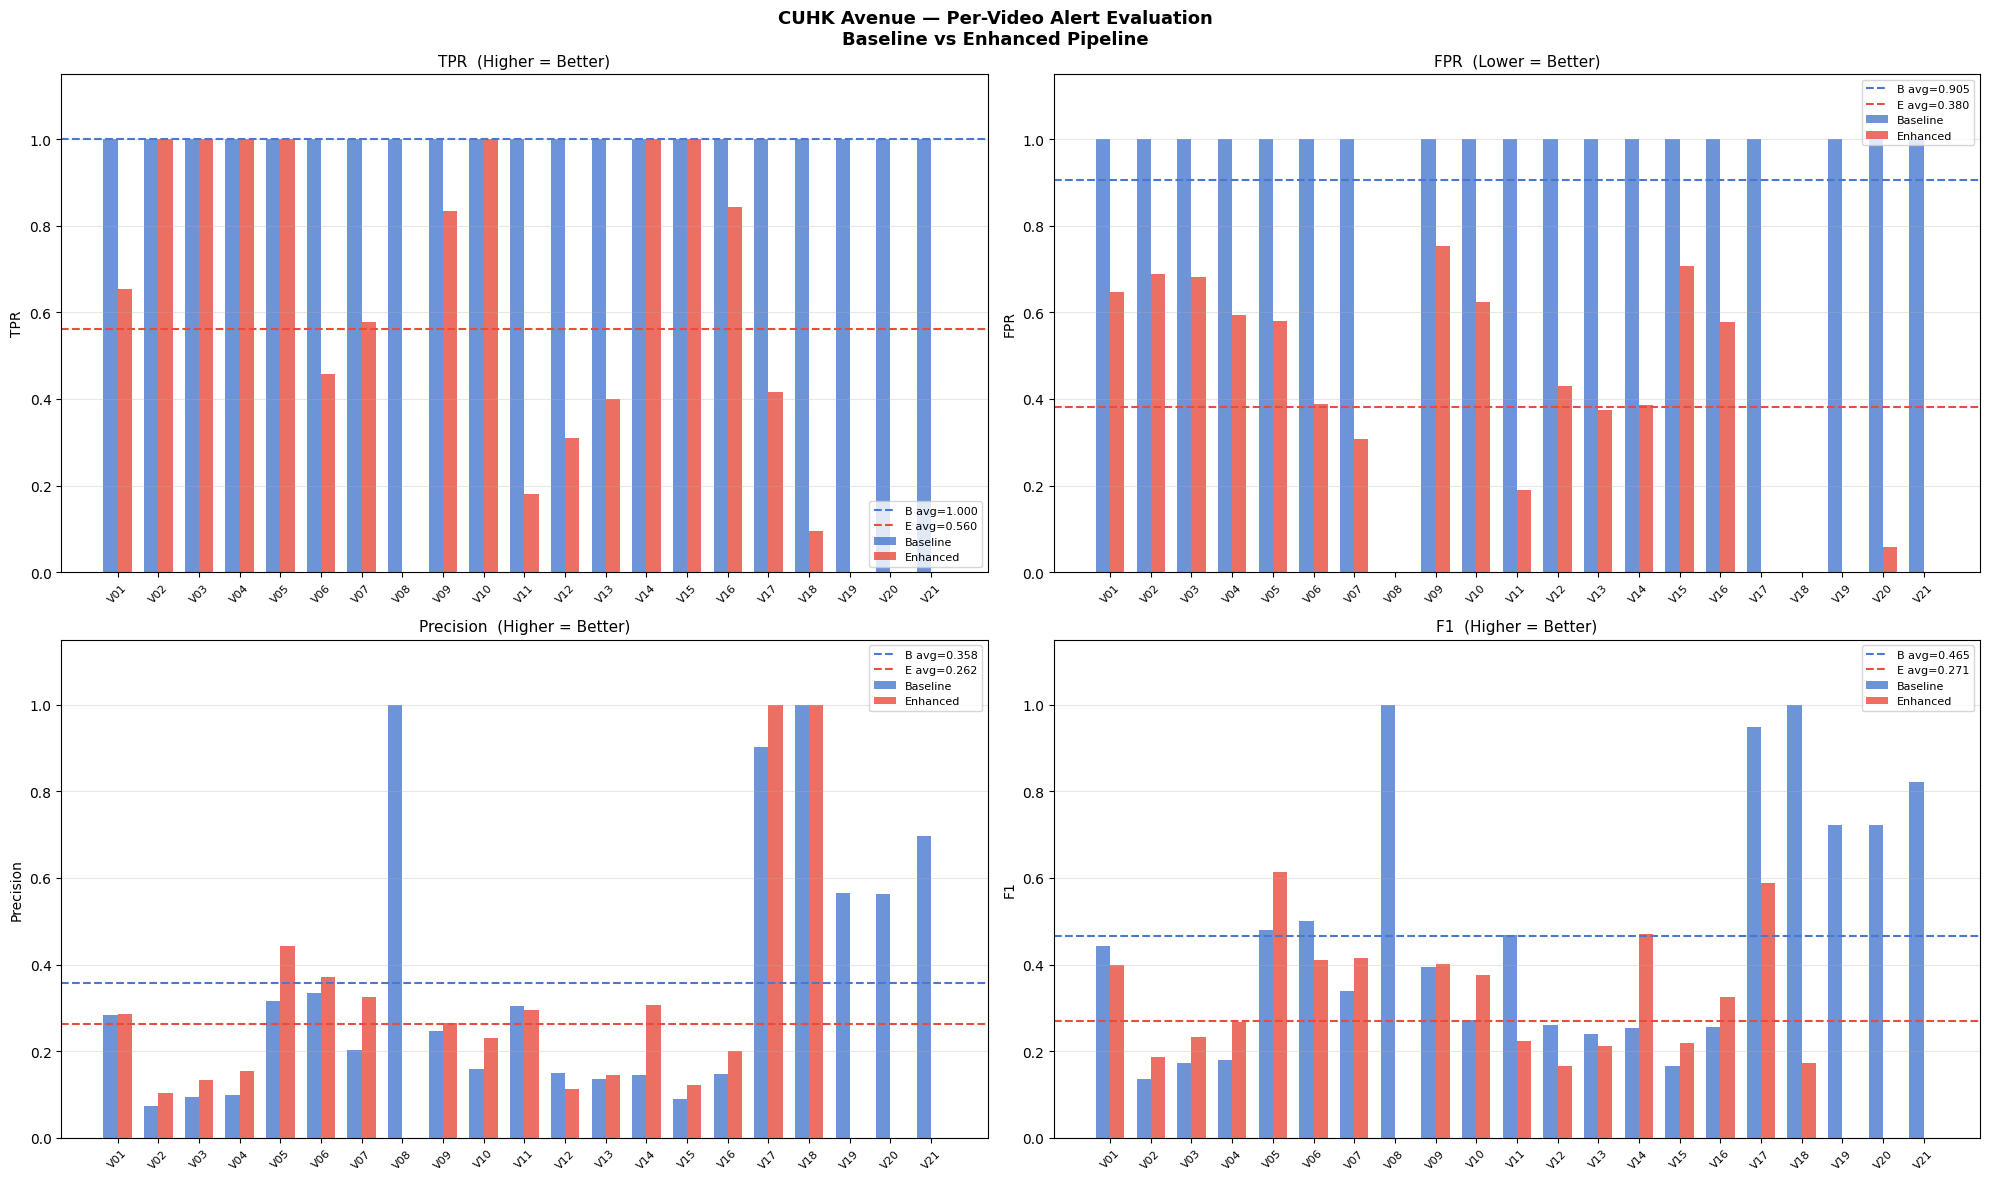

In [8]:
if alert_results:
    vid_ids = sorted(alert_results.keys())
    metrics_to_plot = ['TPR', 'FPR', 'Precision', 'F1']
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))

    for ax, metric in zip(axes.flatten(), metrics_to_plot):
        b_vals = [alert_results[v]['baseline'][metric] for v in vid_ids]
        e_vals = [alert_results[v]['enhanced'][metric]  for v in vid_ids]
        x = np.arange(len(vid_ids)); w = 0.35
        ax.bar(x-w/2, b_vals, w, label='Baseline', color=COLOR_B, alpha=0.8)
        ax.bar(x+w/2, e_vals, w, label='Enhanced', color=COLOR_E, alpha=0.8)
        # horizontal lines for averages
        ax.axhline(np.mean(b_vals), color=COLOR_B, linestyle='--', linewidth=1.5,
                   label=f'B avg={np.mean(b_vals):.3f}')
        ax.axhline(np.mean(e_vals), color=COLOR_E, linestyle='--', linewidth=1.5,
                   label=f'E avg={np.mean(e_vals):.3f}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'V{v:02d}' for v in vid_ids], fontsize=8, rotation=45)
        ax.set_ylim(0, 1.15); ax.set_ylabel(metric)
        note = '(Higher = Better)' if metric != 'FPR' else '(Lower = Better)'
        ax.set_title(f'{metric}  {note}', fontsize=11)
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

    plt.suptitle('CUHK Avenue — Per-Video Alert Evaluation\nBaseline vs Enhanced Pipeline',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8) Aggregate Metric Bar Chart

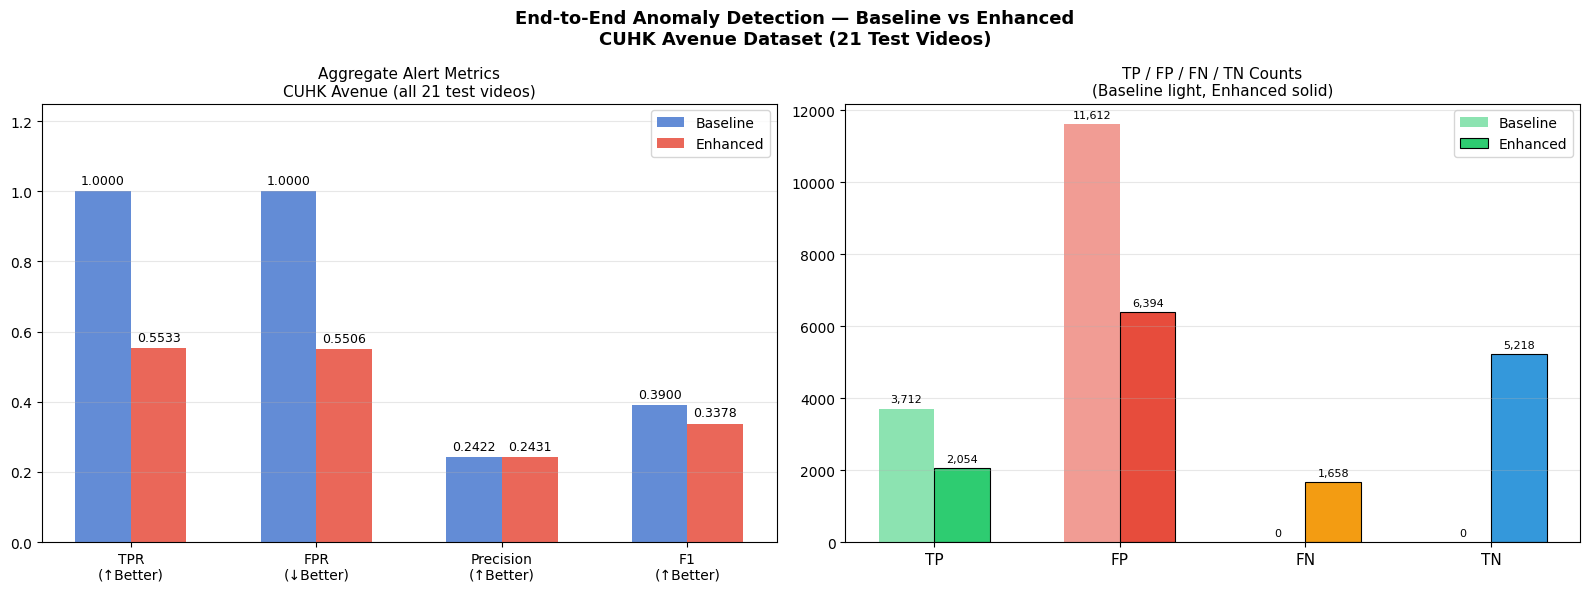

In [9]:
if alert_results:
    metrics_b = calc_metrics(agg_b)
    metrics_e = calc_metrics(agg_e)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left — TPR / FPR / Precision / F1
    mkeys = ['TPR','FPR','Precision','F1']
    bv = [metrics_b[m] for m in mkeys]
    ev = [metrics_e[m] for m in mkeys]
    x = np.arange(len(mkeys)); w = 0.30
    b1 = axes[0].bar(x-w/2, bv, w, label='Baseline', color=COLOR_B, alpha=0.85)
    b2 = axes[0].bar(x+w/2, ev, w, label='Enhanced', color=COLOR_E, alpha=0.85)
    axes[0].bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
    axes[0].bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(['TPR\n(↑Better)','FPR\n(↓Better)',
                              'Precision\n(↑Better)','F1\n(↑Better)'], fontsize=10)
    axes[0].set_ylim(0, 1.25); axes[0].legend(fontsize=10)
    axes[0].set_title('Aggregate Alert Metrics\nCUHK Avenue (all 21 test videos)', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)

    # Right — TP/FP/FN/TN counts
    ck = ['TP','FP','FN','TN']
    bc = [agg_b[k] for k in ck]
    ec = [agg_e[k] for k in ck]
    colors_c = ['#2ECC71','#E74C3C','#F39C12','#3498DB']
    x2 = np.arange(len(ck))
    b3 = axes[1].bar(x2-w/2, bc, w, color=colors_c, alpha=0.55, label='Baseline')
    b4 = axes[1].bar(x2+w/2, ec, w, color=colors_c, alpha=1.0,  label='Enhanced',
                     edgecolor='black', linewidth=0.8)
    axes[1].bar_label(b3, labels=[f'{v:,}' for v in bc], padding=3, fontsize=8)
    axes[1].bar_label(b4, labels=[f'{v:,}' for v in ec], padding=3, fontsize=8)
    axes[1].set_xticks(x2); axes[1].set_xticklabels(ck, fontsize=11)
    axes[1].set_title('TP / FP / FN / TN Counts\n(Baseline light, Enhanced solid)', fontsize=11)
    axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle('End-to-End Anomaly Detection — Baseline vs Enhanced\nCUHK Avenue Dataset (21 Test Videos)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 9) Per-Frame Alert Timeline (Sample Videos)

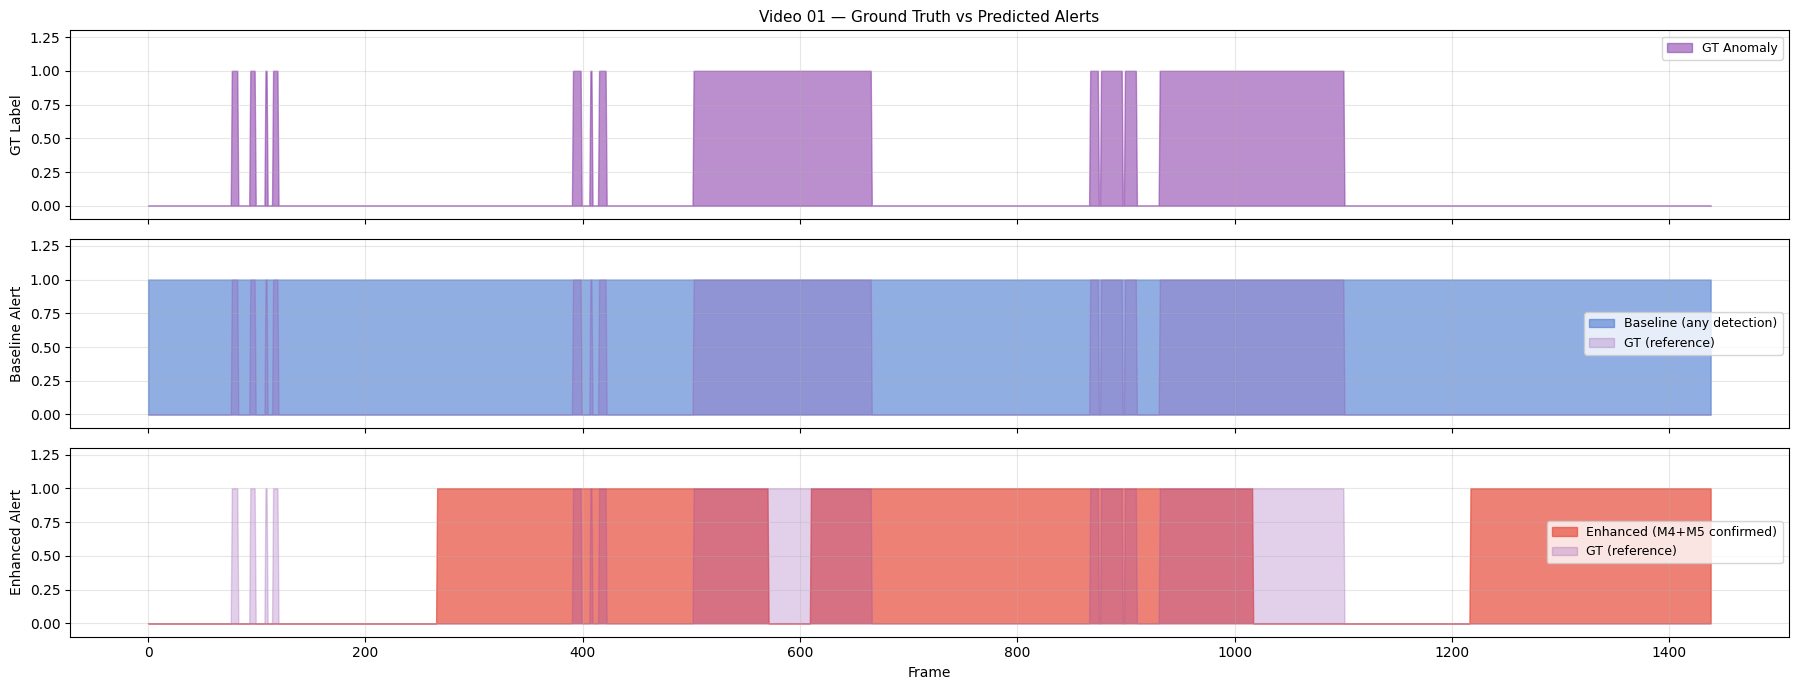

Video 01:  Baseline TPR=1.000 FPR=1.000 F1=0.442  |  Enhanced TPR=0.654 FPR=0.647 F1=0.398



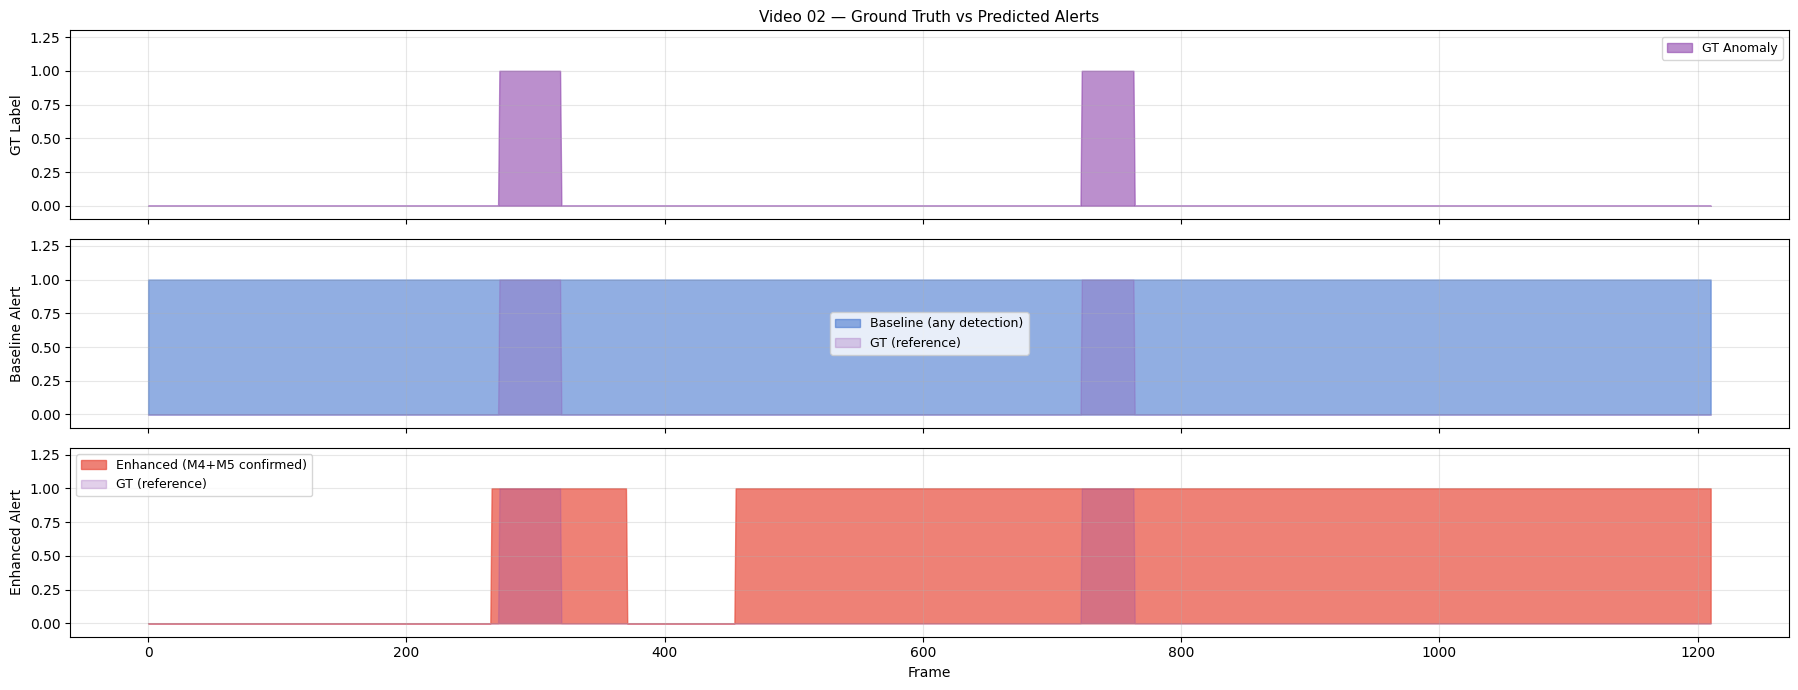

Video 02:  Baseline TPR=1.000 FPR=1.000 F1=0.137  |  Enhanced TPR=1.000 FPR=0.688 F1=0.187



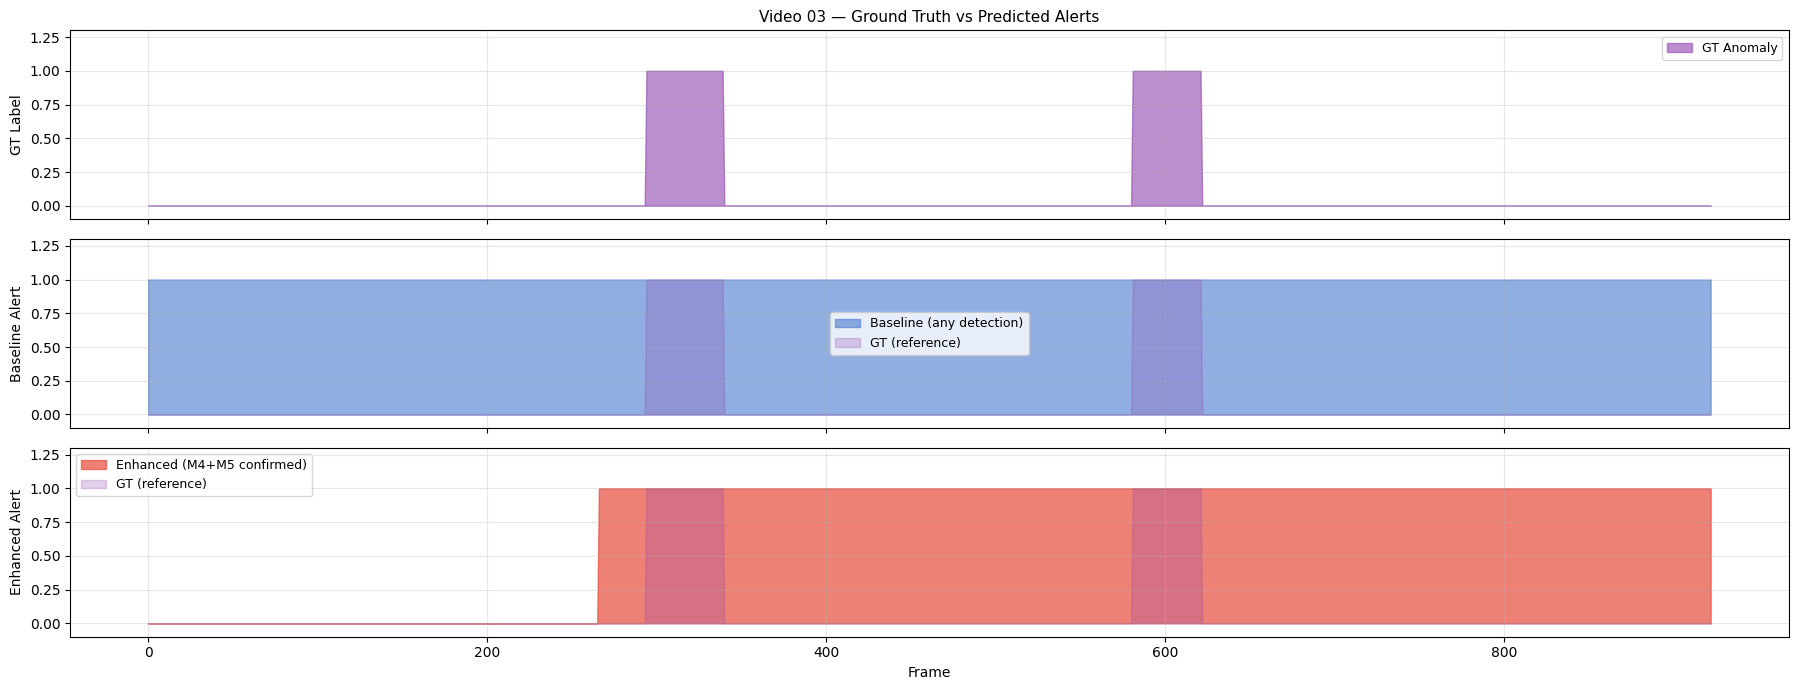

Video 03:  Baseline TPR=1.000 FPR=1.000 F1=0.172  |  Enhanced TPR=1.000 FPR=0.682 F1=0.234



In [10]:
# Plot timeline for first 3 videos with GT
sample_ids = [v for v in sorted(alert_results.keys())][:3]

for vid_id in sample_ids:
    gt_flags = avenue_results[vid_id]['gt_flags']
    pf_e = alert_results[vid_id]['enhanced']['per_frame']
    pf_b = alert_results[vid_id]['baseline']['per_frame']

    frames   = [d['frame'] for d in pf_e]
    gt_line  = [d['gt']   for d in pf_e]
    pred_e   = [d['pred'] for d in pf_e]
    pred_b   = [d['pred'] for d in pf_b]

    fig, axes = plt.subplots(3, 1, figsize=(18, 7), sharex=True)

    axes[0].fill_between(frames, gt_line, color='#8E44AD', alpha=0.6, label='GT Anomaly')
    axes[0].set_ylabel('GT Label'); axes[0].set_ylim(-0.1,1.3)
    axes[0].set_title(f'Video {vid_id:02d} — Ground Truth vs Predicted Alerts', fontsize=11)
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

    axes[1].fill_between(frames, pred_b, color=COLOR_B, alpha=0.6, label='Baseline (any detection)')
    axes[1].fill_between(frames, gt_line, color='#8E44AD', alpha=0.25, label='GT (reference)')
    axes[1].set_ylabel('Baseline Alert'); axes[1].set_ylim(-0.1,1.3)
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    axes[2].fill_between(frames, pred_e, color=COLOR_E, alpha=0.7, label='Enhanced (M4+M5 confirmed)')
    axes[2].fill_between(frames, gt_line, color='#8E44AD', alpha=0.25, label='GT (reference)')
    axes[2].set_ylabel('Enhanced Alert'); axes[2].set_xlabel('Frame')
    axes[2].set_ylim(-0.1,1.3); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    ev_b = alert_results[vid_id]['baseline']
    ev_e = alert_results[vid_id]['enhanced']
    print(f'Video {vid_id:02d}:  Baseline TPR={ev_b["TPR"]:.3f} FPR={ev_b["FPR"]:.3f} F1={ev_b["F1"]:.3f}'
          f'  |  Enhanced TPR={ev_e["TPR"]:.3f} FPR={ev_e["FPR"]:.3f} F1={ev_e["F1"]:.3f}')
    print()

## 10) Detection Count Comparison (Avg Det/Frame)

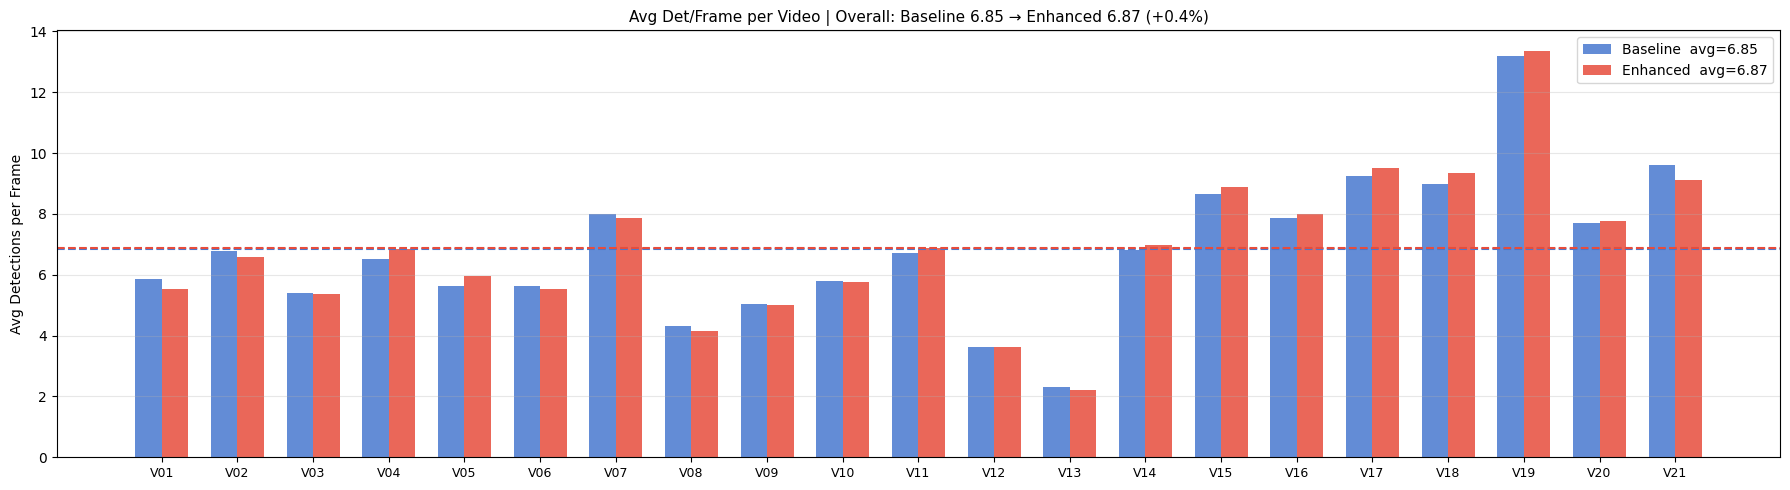

In [11]:
vid_ids  = sorted(avenue_results.keys())
avg_b = [np.mean([r['count'] for r in avenue_results[v]['baseline']]) for v in vid_ids]
avg_e = [np.mean([r['count'] for r in avenue_results[v]['enhanced']]) for v in vid_ids]

fig, ax = plt.subplots(figsize=(18, 5))
x = np.arange(len(vid_ids)); w = 0.35
ax.bar(x-w/2, avg_b, w, label=f'Baseline  avg={np.mean(avg_b):.2f}', color=COLOR_B, alpha=0.85)
ax.bar(x+w/2, avg_e, w, label=f'Enhanced  avg={np.mean(avg_e):.2f}', color=COLOR_E, alpha=0.85)
ax.axhline(np.mean(avg_b), color=COLOR_B, linestyle='--', linewidth=1.5)
ax.axhline(np.mean(avg_e), color=COLOR_E, linestyle='--', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels([f'V{v:02d}' for v in vid_ids], fontsize=9)
ax.set_ylabel('Avg Detections per Frame')
imp = (np.mean(avg_e)-np.mean(avg_b))/max(np.mean(avg_b),1e-6)*100
ax.set_title(f'Avg Det/Frame per Video | Overall: Baseline {np.mean(avg_b):.2f} → Enhanced {np.mean(avg_e):.2f} '
             f'({("+" if imp>=0 else "")}{imp:.1f}%)', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11) M4+M5 Alert Pipeline — Potential vs Confirmed

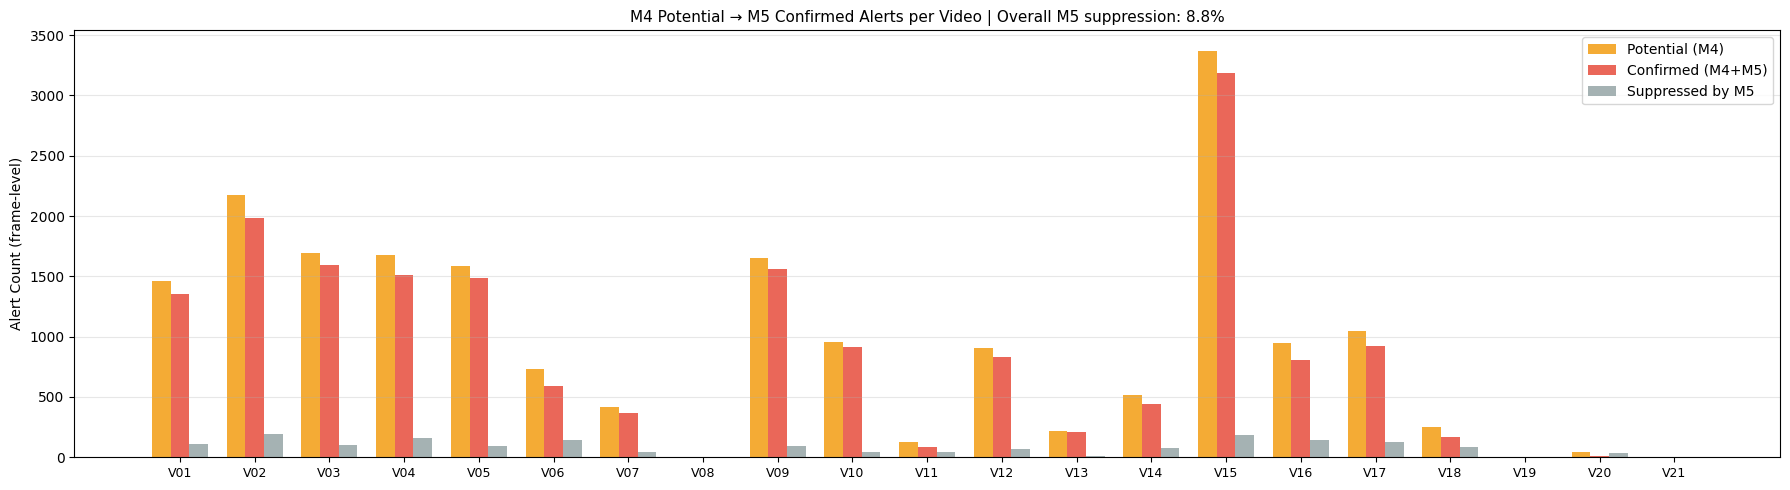

Total potential alerts (M4) : 19,776
Total confirmed alerts (M5) : 18,031
Total suppressed by M5      : 1,745  (8.8%)


In [12]:
vid_ids   = sorted(avenue_results.keys())
n_pot_all  = [sum(len(r.get('potential_ids',[])) for r in avenue_results[v]['enhanced']) for v in vid_ids]
n_conf_all = [sum(len(r.get('confirmed_ids',[])) for r in avenue_results[v]['enhanced']) for v in vid_ids]
n_supp_all = [max(p-c,0) for p,c in zip(n_pot_all,n_conf_all)]

fig, ax = plt.subplots(figsize=(18, 5))
x = np.arange(len(vid_ids)); w = 0.25
ax.bar(x-w,   n_pot_all,  w, label='Potential (M4)',     color='#F39C12', alpha=0.85)
ax.bar(x,     n_conf_all, w, label='Confirmed (M4+M5)',  color='#E74C3C', alpha=0.85)
ax.bar(x+w,   n_supp_all, w, label='Suppressed by M5',   color='#95A5A6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'V{v:02d}' for v in vid_ids], fontsize=9)
ax.set_ylabel('Alert Count (frame-level)')
total_supp_pct = 100*sum(n_supp_all)/max(sum(n_pot_all),1)
ax.set_title(f'M4 Potential → M5 Confirmed Alerts per Video | '
             f'Overall M5 suppression: {total_supp_pct:.1f}%', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total potential alerts (M4) : {sum(n_pot_all):,}')
print(f'Total confirmed alerts (M5) : {sum(n_conf_all):,}')
print(f'Total suppressed by M5      : {sum(n_supp_all):,}  ({total_supp_pct:.1f}%)')

## 12) Side-by-Side Frame Samples — Anomalous vs Normal Frames

Sample video path: ../evaluationDataset\Avenue Dataset\testing_videos\01.avi
GT available: True
Anomalous frames sampled : [77, 78]
Normal frames sampled    : [0, 1]


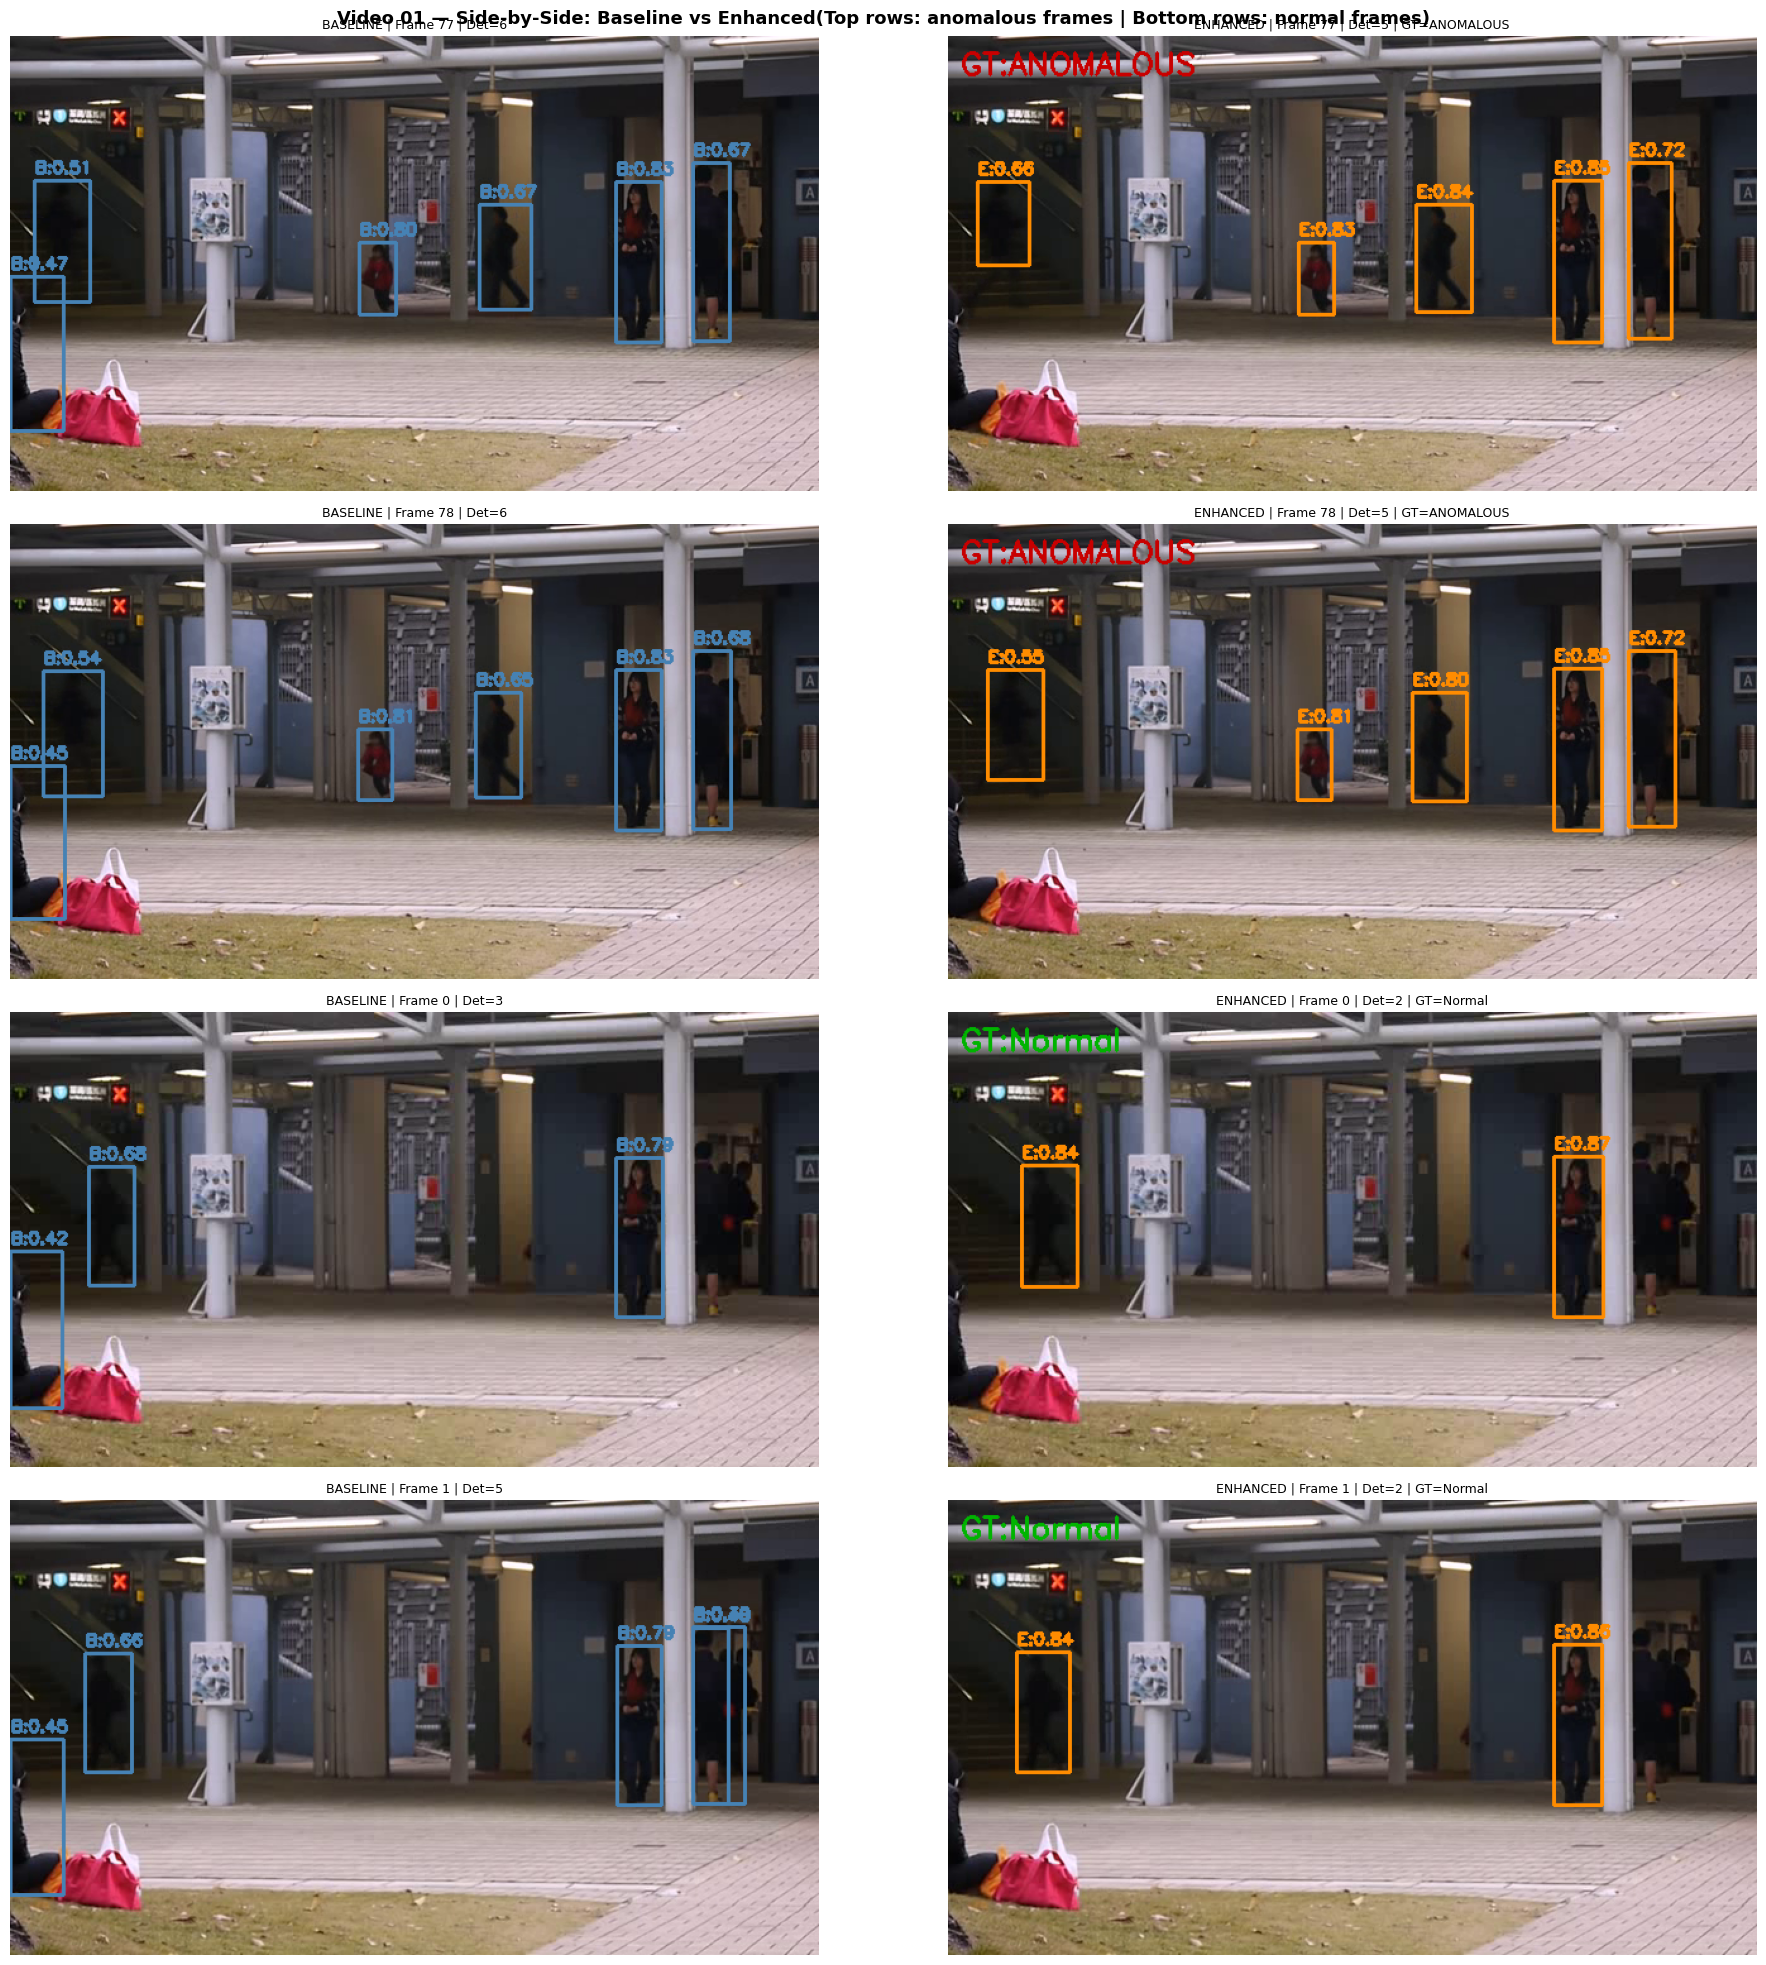

In [13]:
def draw_boxes(frame, boxes, color, label_prefix=""):
    out = frame.copy()
    for (x1,y1,x2,y2,conf) in boxes:
        cv2.rectangle(out,(x1,y1),(x2,y2),color,2)
        cv2.putText(out,f"{label_prefix}{conf:.2f}",
                    (x1,max(0,y1-6)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,2)
    return out

# ── Resolve video path using the same fallback logic as Section 4 ──────────
def resolve_vid_path(avenue_root, vid_id):
    for subdir in ["Avenue Dataset", "testing_videos", "Avenue_Dataset"]:
        if subdir == "Avenue Dataset" or subdir == "Avenue_Dataset":
            p = os.path.join(avenue_root, subdir, "testing_videos", f"{vid_id:02d}.avi")
        else:
            p = os.path.join(avenue_root, subdir, f"{vid_id:02d}.avi")
        if os.path.exists(p):
            return p
    return None

# ── Build frame-index lookup dicts (frame_id -> record) ────────────────────
SAMPLE_VID = sorted(avenue_results.keys())[0]
res      = avenue_results[SAMPLE_VID]
gt_flags = res["gt_flags"]
rec_b    = res["baseline"]
rec_e    = res["enhanced"]

# Build lookup by frame id so we can safely index by frame number
rec_b_by_frame = {r["frame"]: r for r in rec_b}
rec_e_by_frame = {r["frame"]: r for r in rec_e}

vpath = resolve_vid_path(AVENUE_ROOT, SAMPLE_VID)
print(f"Sample video path: {vpath}")
print(f"GT available: {gt_flags is not None}")

if gt_flags is not None and vpath is not None:
    # Find 2 anomalous + 2 normal frames that have detections
    anom_frames   = [r["frame"] for r in rec_e
                     if r["frame"] < len(gt_flags)
                     and gt_flags[r["frame"]] == 1
                     and r["count"] > 0][:2]
    normal_frames = [r["frame"] for r in rec_e
                     if r["frame"] < len(gt_flags)
                     and gt_flags[r["frame"]] == 0
                     and r["count"] > 0][:2]
    sample_frames = anom_frames + normal_frames
    print(f"Anomalous frames sampled : {anom_frames}")
    print(f"Normal frames sampled    : {normal_frames}")

    cap_b = cv2.VideoCapture(vpath)
    cap_e = cv2.VideoCapture(vpath)
    fig, axes = plt.subplots(len(sample_frames), 2,
                             figsize=(20, 5 * len(sample_frames)))
    # ensure axes is always 2-D
    if len(sample_frames) == 1:
        axes = [axes]

    for row_ax, fidx in zip(axes, sample_frames):
        cap_b.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        cap_e.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        _, fb = cap_b.read()
        _, fe = cap_e.read()
        if fb is None or fe is None:
            print(f"  Frame {fidx}: could not read from video")
            continue

        rb = rec_b_by_frame.get(fidx, {"det_boxes": [], "count": 0})
        re = rec_e_by_frame.get(fidx, {"det_boxes": [], "count": 0,
                                         "confirmed_ids": []})

        ann_b = draw_boxes(fb, rb["det_boxes"], (180,130,70), "B:")
        ann_e = draw_boxes(fe, re["det_boxes"], (0,140,255),  "E:")

        gt_lbl = "ANOMALOUS" if gt_flags[fidx] == 1 else "Normal"
        gt_col = (0,0,200) if gt_flags[fidx] == 1 else (0,180,0)
        conf_e = len(re.get("confirmed_ids", []))

        cv2.putText(ann_e, f"GT:{gt_lbl}", (10,30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, gt_col, 2)
        if conf_e > 0:
            cv2.putText(ann_e, "ALERT!", (10,65),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,255), 3)

        row_ax[0].imshow(cv2.cvtColor(ann_b, cv2.COLOR_BGR2RGB))
        row_ax[0].set_title(
            f"BASELINE | Frame {fidx} | Det={rb['count']}", fontsize=9)
        row_ax[0].axis("off")
        row_ax[1].imshow(cv2.cvtColor(ann_e, cv2.COLOR_BGR2RGB))
        row_ax[1].set_title(
            f"ENHANCED | Frame {fidx} | Det={re['count']} | GT={gt_lbl}", fontsize=9)
        row_ax[1].axis("off")

    cap_b.release(); cap_e.release()
    plt.suptitle(f"Video {SAMPLE_VID:02d} — Side-by-Side: Baseline vs Enhanced"
                 f"(Top rows: anomalous frames | Bottom rows: normal frames)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find video file for Video {SAMPLE_VID:02d}")
    print(f"Searched AVENUE_ROOT={AVENUE_ROOT}")
    print("Check that .avi files exist in: Avenue Dataset/testing_videos/")


## 13) Final Printed Report

In [16]:
SEP = '='*65
print(SEP)
print('  CUHK AVENUE — FULL PIPELINE EVALUATION REPORT')
print('  Baseline (COCO yolov8n, detection only)')
print('  Enhanced (Fine-tuned LLVIP-only dark-condition YOLO + DeepSORT + M4+M5 pipeline)')
print(SEP)

if alert_results:
    agg_b = defaultdict(int)
    agg_e = defaultdict(int)
    for v, r in alert_results.items():
        for k in ['TP','FP','FN','TN']:
            agg_b[k] += r['baseline'][k]
            agg_e[k] += r['enhanced'][k]
    metrics_b = calc_metrics(agg_b)
    metrics_e = calc_metrics(agg_e)

    print(f'\n  Videos evaluated : {len(alert_results)} / 21')
    print(f'\n  {"Metric":<14} {"Baseline":>10} {"Enhanced":>10} {"Change":>10}')
    print(f'  {"-"*50}')
    for m in ['TPR','FPR','Precision','F1']:
        bv = metrics_b[m]; ev = metrics_e[m]
        delta = ev - bv
        better = '✅' if (m != 'FPR' and delta > 0) or (m == 'FPR' and delta < 0) else '❌'
        print(f'  {m:<14} {bv:>10.4f} {ev:>10.4f} {("+" if delta>=0 else "")}{delta:>+9.4f}  {better}')

    print(f'\n  {"Count":<14} {"Baseline":>10} {"Enhanced":>10} {"Change":>10}')
    print(f'  {"-"*50}')
    for k in ['TP','FP','FN','TN']:
        bv = agg_b[k]; ev = agg_e[k]
        print(f'  {k:<14} {bv:>10,} {ev:>10,} {ev-bv:>+10,}')

    total_pot  = sum(sum(len(r.get('potential_ids',[])) for r in avenue_results[v]['enhanced'])
                     for v in avenue_results)
    total_conf = sum(sum(len(r.get('confirmed_ids',[]))  for r in avenue_results[v]['enhanced'])
                     for v in avenue_results)
    supp_pct   = 100*(total_pot-total_conf)/max(total_pot,1)
    print(f'\n  M4 potential alerts : {total_pot:,}')
    print(f'  M5 confirmed alerts : {total_conf:,}')
    print(f'  M5 suppression rate : {supp_pct:.1f}%')

print()
print(SEP)
print('  KEY NOTES')
print(SEP)
print('  • Baseline alert proxy = any detection in frame (no loitering logic)')
print('  • Enhanced alert      = M4 dwell-time flag + M5 15-frame stability')
print('  • GT anomaly label    = 1 if ANY anomaly pixel present in frame')
print('  • Avenue resolution   : 640×360, horizontal-angle campus camera')
print('  • Zone polygon        : covers most of frame (adjust for tighter test)')

  CUHK AVENUE — FULL PIPELINE EVALUATION REPORT
  Baseline (COCO yolov8n, detection only)
  Enhanced (Fine-tuned LLVIP-only dark-condition YOLO + DeepSORT + M4+M5 pipeline)

  Videos evaluated : 21 / 21

  Metric           Baseline   Enhanced     Change
  --------------------------------------------------
  TPR                1.0000     0.5533   -0.4467  ❌
  FPR                1.0000     0.5506   -0.4494  ✅
  Precision          0.2422     0.2431 +  +0.0009  ✅
  F1                 0.3900     0.3378   -0.0522  ❌

  Count            Baseline   Enhanced     Change
  --------------------------------------------------
  TP                  3,712      2,054     -1,658
  FP                 11,612      6,394     -5,218
  FN                      0      1,658     +1,658
  TN                      0      5,218     +5,218

  M4 potential alerts : 19,776
  M5 confirmed alerts : 18,031
  M5 suppression rate : 8.8%

  KEY NOTES
  • Baseline alert proxy = any detection in frame (no loitering logic)
  • 

## 14) Live Inference Demo Video

Writes a **side-by-side MP4** showing Baseline vs Enhanced on any chosen test video.

**Left panel — Baseline**
- Orange bounding boxes (raw YOLOv8n COCO detections)

**Right panel — Enhanced**
- Blue bounding boxes (fine-tuned detections)
- Yellow zone polygon overlay
- Centroid dot per tracked person:
  - 🟢 **Green** — tracked, in zone, dwell time < threshold
  - 🟡 **Yellow** — M4 flagged (potential loitering, awaiting M5 confirmation)
  - 🔴 **Red** — M5 confirmed loitering alert
- Dwell-time timer label per ID
- **LOITERING ALERT** banner when M5 confirms

**GT header bar** (top strip)
- 🟣 Purple = GT anomalous frame
- 🟢 Dark green = GT normal frame

Output saved as `avenue_demo_XX.mp4` next to the notebook.
Run the **Preview cell** below to see the first frame without opening a media player.

In [ ]:
import gc

# ── CONFIGURE HERE ───────────────────────────────────────────────────────────
DEMO_VID_ID    = 1       # 1–21 — which Avenue test video to render
DEMO_MAX_FRAMES = None   # None = full video  |  e.g. 300 = quick test
# ─────────────────────────────────────────────────────────────────────────────

DEMO_OUTPUT = f'avenue_demo_{DEMO_VID_ID:02d}.mp4'


def _resolve_vpath(root, vid_id):
    candidates = [
        os.path.join(root, 'Avenue Dataset', 'testing_videos', f'{vid_id:02d}.avi'),
        os.path.join(root, 'Avenue_Dataset', 'testing_videos', f'{vid_id:02d}.avi'),
        os.path.join(root, 'testing_videos', f'{vid_id:02d}.avi'),
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return None


def render_avenue_demo(vid_id, output_path, max_frames=None):

    vpath = _resolve_vpath(AVENUE_ROOT, vid_id)
    if not vpath:
        print(f'ERROR: .avi not found for Video {vid_id:02d}. Check AVENUE_ROOT.')
        return

    # Load GT flags
    gt_flags = None
    try:
        gt_flags = load_avenue_gt(GT_ROOT, vid_id)
    except Exception as e:
        print(f'Warning — GT not loaded: {e}')

    # ── Open source video ─────────────────────────────────────────────────────
    cap_info = cv2.VideoCapture(vpath)
    fps_v  = cap_info.get(cv2.CAP_PROP_FPS) or 25.0
    src_w  = int(cap_info.get(cv2.CAP_PROP_FRAME_WIDTH))
    src_h  = int(cap_info.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n_tot  = int(cap_info.get(cv2.CAP_PROP_FRAME_COUNT))
    cap_info.release()

    limit  = min(n_tot, max_frames) if max_frames else n_tot
    HEADER = 32                          # pixels for GT label strip at top
    out_w  = src_w * 2
    out_h  = src_h + HEADER

    print(f'Video {vid_id:02d}: {src_w}x{src_h}  {fps_v:.1f}fps  {n_tot} frames')
    print(f'Rendering {limit} frames -> {output_path}')

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_path, fourcc, fps_v, (out_w, out_h))

    # ── Fresh pipeline instances ───────────────────────────────────────────────
    det_b    = PersonDetectionModule(BASELINE_WEIGHTS, conf=CONF_THRESHOLD, iou=NMS_IOU_BASELINE)
    det_e    = PersonDetectionModule(ENHANCED_WEIGHTS,  conf=CONF_THRESHOLD, iou=NMS_IOU_ENHANCED)
    tracker  = DeepSORTTracker(max_age=40, n_init=3, max_cosine_distance=0.3, nn_budget=100)
    analyzer = SpatioTemporalModule(fps=fps_v, loitering_threshold=10.0,
                                    zone_polygon=ZONE_POLYGON)
    reducer  = FalsePositiveReductionModule(persistence_threshold=15)

    # Colours (BGR)
    COL_BOX_B  = ( 50, 150, 255)   # baseline box  — orange
    COL_BOX_E  = (255, 160,  30)   # enhanced box  — blue
    COL_ZONE   = (  0, 230, 230)   # zone outline  — yellow
    COL_OK     = (  0, 200,   0)   # centroid ok   — green
    COL_PEND   = (  0, 220, 220)   # M4 pending    — yellow
    COL_ALERT  = (  0,   0, 220)   # M5 confirmed  — red
    COL_LTEXT  = (255, 255, 255)
    COL_SHADOW = ( 30,  30,  30)

    cap = cv2.VideoCapture(vpath)
    f_i = 0

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames and f_i >= max_frames):
            break

        # ── BASELINE panel ────────────────────────────────────────────────────
        dets_b = det_b.detect(frame)
        pan_b  = frame.copy()
        for (x1,y1,x2,y2,cf) in dets_b:
            cv2.rectangle(pan_b, (x1,y1), (x2,y2), COL_BOX_B, 2)
            cv2.putText(pan_b, f'{cf:.2f}', (x1, max(6,y1-4)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38, COL_BOX_B, 1)
        # bottom-left label (shadow + colour)
        for col, thick in [(COL_SHADOW,3),(COL_LTEXT,1)]:
            cv2.putText(pan_b, f'BASELINE  |  det={len(dets_b)}',
                        (8, src_h-8), cv2.FONT_HERSHEY_SIMPLEX, 0.52, col, thick)

        # ── ENHANCED panel (M2→M3→M4→M5) ─────────────────────────────────────
        dets_e = det_e.detect(frame)
        tracked, tracked_boxes = tracker.update(frame, dets_e)

        pot_ids, timers = analyzer.process(tracked)
        conf_ids = [oid for oid in pot_ids if reducer.validate(oid, True)]

        for oid in tracked:
            if oid not in pot_ids:
                reducer.validate(oid, False)

        pan_e = frame.copy()

        # Zone polygon
        cv2.polylines(pan_e, [ZONE_POLYGON], True, COL_ZONE, 2)
        cv2.putText(pan_e, 'ZONE',
                    (ZONE_POLYGON[0][0] + 4, ZONE_POLYGON[0][1] + 16),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, COL_ZONE, 1)

        for oid, (x1, y1, x2, y2) in tracked_boxes.items():
            cx, cy = tracked[oid]
            secs = timers.get(oid, 0) / fps_v

            if oid in conf_ids:
                col = COL_ALERT
                label = f'ID{oid} {secs:.1f}s ALERT'
            elif oid in pot_ids:
                col = COL_PEND
                label = f'ID{oid} {secs:.1f}s ?'
            else:
                col = COL_OK
                label = f'ID{oid} {secs:.1f}s'

            cv2.rectangle(pan_e, (x1, y1), (x2, y2), col, 2)
            cv2.putText(pan_e, label, (x1, max(15, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, col, 1)

            cv2.circle(pan_e, (int(cx), int(cy)), 4, col, -1)

        # Tracked centroids with status
        for oid, centroid in tracked.items():
            cx, cy = int(centroid[0]), int(centroid[1])
            secs   = timers.get(oid, 0) / fps_v

            if oid in conf_ids:
                col   = COL_ALERT
                tlabel = f'ID{oid}  {secs:.1f}s  ALERT'
                # Alert banner above centroid
                bx1, by1 = cx - 2, cy - 38
                bx2, by2 = cx + 120, cy - 20
                cv2.rectangle(pan_e, (bx1,by1), (bx2,by2), COL_ALERT, -1)
                cv2.putText(pan_e, 'LOITERING', (bx1+4, by2-3),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.42, COL_LTEXT, 1)
            elif oid in pot_ids:
                col    = COL_PEND
                tlabel = f'ID{oid}  {secs:.1f}s  ?'
            else:
                col    = COL_OK
                tlabel = f'ID{oid}  {secs:.1f}s'

            # Dot + white outline
            cv2.circle(pan_e, (cx,cy), 6, col, -1)
            cv2.circle(pan_e, (cx,cy), 6, (255,255,255), 1)
            # Label shadow then colour
            cv2.putText(pan_e, tlabel, (cx-8, cy-12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, COL_SHADOW, 2)
            cv2.putText(pan_e, tlabel, (cx-8, cy-12),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.40, col, 1)

        # Bottom status bar
        status = (f'ENHANCED  |  det={len(dets_e)}  '
                  f'tracked={len(tracked)}  alerts={len(conf_ids)}')
        for col, thick in [(COL_SHADOW,3),(COL_LTEXT,1)]:
            cv2.putText(pan_e, status, (8, src_h-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.52, col, thick)

        # ── Stitch + header ───────────────────────────────────────────────────
        combined = np.hstack([pan_b, pan_e])

        # Divider line
        cv2.line(combined, (src_w,0), (src_w, src_h), (180,180,180), 2)

        # GT header strip
        hdr = np.zeros((HEADER, out_w, 3), dtype=np.uint8)
        gt_flag = int(gt_flags[f_i]) if (gt_flags is not None
                                         and f_i < len(gt_flags)) else -1
        if gt_flag == 1:
            hdr[:] = (100, 0, 140)
            gt_txt = f'GT: ANOMALOUS   Frame {f_i:04d} / {limit}'
        elif gt_flag == 0:
            hdr[:] = (20, 55, 20)
            gt_txt = f'GT: Normal      Frame {f_i:04d} / {limit}'
        else:
            hdr[:] = (35, 35, 35)
            gt_txt = f'GT: –           Frame {f_i:04d} / {limit}'

        cv2.putText(hdr, gt_txt, (out_w//2 - 160, HEADER-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.58, (230,230,230), 1)

        out_frame = np.vstack([hdr, combined])
        writer.write(out_frame)
        f_i += 1

        if f_i % 100 == 0:
            pct = 100 * f_i / limit
            print(f'  {f_i}/{limit}  ({pct:.0f}%)', end='\r')

    cap.release()
    writer.release()
    gc.collect()
    print(f'\n✅ Saved: {output_path}  ({f_i} frames)')

# ── Run ───────────────────────────────────────────────────────────────────────
render_avenue_demo(DEMO_VID_ID, DEMO_OUTPUT, DEMO_MAX_FRAMES)